In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Digital_Distraction.csv')
df.head(5)

,Age,Daily_Screen_Time,Social_Media_Time,Notifications,App_Switches,Sleep_Hours,Work_Hours,Distraction_Level
0,22,3.96,1.70,175,73,7.86,3.07,0
1,35,2.69,2.70,130,26,4.14,7.04,0
2,30,3.01,6.06,153,18,4.33,2.43,0
3,26,2.18,6.99,127,50,6.32,7.99,0
4,23,2.94,6.81,167,10,8.55,4.54,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                520 non-null    int64  
 1   Daily_Screen_Time  520 non-null    float64
 2   Social_Media_Time  520 non-null    float64
 3   Notifications      520 non-null    int64  
 4   App_Switches       520 non-null    int64  
 5   Sleep_Hours        520 non-null    float64
 6   Work_Hours         520 non-null    float64
 7   Distraction_Level  520 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 32.6 KB


In [4]:
df.isna().sum()

Age                  0
Daily_Screen_Time    0
Social_Media_Time    0
Notifications        0
App_Switches         0
Sleep_Hours          0
Work_Hours           0
Distraction_Level    0
dtype: int64

In [5]:
df.describe()

,Age,Daily_Screen_Time,Social_Media_Time,Notifications,App_Switches,Sleep_Hours,Work_Hours,Distraction_Level
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,27.238462,6.926192,4.546346,111.521154,63.907692,6.526212,5.969135,0.123077
std,7.339343,2.946760,2.067213,52.831462,32.400004,1.430256,2.353929,0.328842
min,16.000000,2.050000,1.040000,20.000000,10.000000,4.010000,2.000000,0.000000
25%,20.000000,4.247500,2.685000,65.750000,33.000000,5.400000,4.010000,0.000000
50%,27.000000,6.925000,4.625000,111.500000,64.500000,6.535000,5.945000,0.000000
75%,34.000000,9.512500,6.372500,160.000000,94.000000,7.770000,7.982500,0.000000
max,39.000000,12.000000,7.990000,199.000000,119.000000,8.990000,9.960000,1.000000


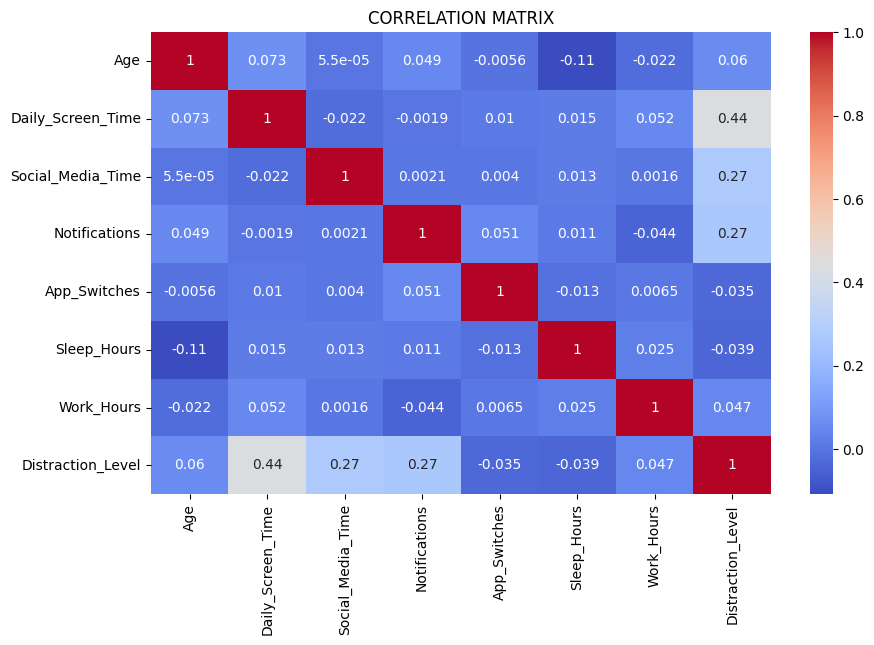

In [7]:
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

In [8]:
#define feature and target
X=df.drop('Distraction_Level',axis=1)
Y=df[['Distraction_Level']]

In [9]:
#preprocessing
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler().set_output(transform='pandas')
X_pre=scaler.fit_transform(X)

In [12]:
import pickle
with open('scaler.pkl','wb')as file1:
    pickle.dump(scaler,file1)

In [13]:
X_pre

,Age,Daily_Screen_Time,Social_Media_Time,Notifications,App_Switches,Sleep_Hours,Work_Hours
0,-0.714438,-1.007564,-1.378226,1.202692,0.280897,0.933451,-1.232801
1,1.058543,-1.438960,-0.894017,0.350107,-1.171117,-1.669988,0.455365
2,0.376627,-1.330262,0.732925,0.785872,-1.418268,-1.537016,-1.504949
3,-0.168905,-1.612199,1.183239,0.293268,-0.429663,-0.144317,0.859334
4,-0.578055,-1.354040,1.096082,1.051121,-1.665420,1.416346,-0.607712
...,...,...,...,...,...,...,...
515,-1.532737,-1.320072,0.776504,-1.355064,-0.862178,-1.271074,-1.011681
516,-1.532737,1.044119,0.534399,-0.957191,1.547547,0.947448,1.297322
517,-0.578055,-1.065310,-0.109599,0.918497,-0.460557,-0.816172,0.825316
518,-0.305289,0.544785,1.144502,0.387999,0.095533,-0.032341,-1.641023


In [18]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X_pre,Y,test_size=0.2,random_state=21)

In [19]:
xtrain.shape

(416, 7)

In [20]:
xtest.shape

(104, 7)

In [21]:
#model building
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
#model evaluation
model.score(xtrain,ytrain)

0.9350961538461539

In [23]:
model.score(xtest,ytest)

0.9038461538461539

In [24]:
with open('model.pkl','wb')as file2:
    pickle.dump(model,file2)

In [ ]:
with open('model.pkl','rb')as file4:
    m=pickle.load(file4)